In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [ ]:
# checking sam2

checkpoint = "#Set_This_Path#/sam2_hiera_large.pt"
model_cfg = "configs/sam2/sam2_hiera_l.yaml"
predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    img_path = "#Set_This_Path#"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    predictor.set_image(img)
    point = [[200,100]]
    label = [1]
    masks, iou_predictions, _ = predictor.predict(point, label)

In [ ]:
!wget https://zenodo.org/records/3697452/files/LabPicsV1.zip
!unzip #Set_This_Path#/LabPicsV1.zip -d labpics

In [ ]:
class LabPics:
    def __init__(self, state="Train"):
        main_path = f"#Set_This_Path#/labpics/LabPicsV1/Simple/{state}"
        image_path = os.path.join(main_path, "Image")
        mask_path = os.path.join(main_path, "Instance")

        imgs, masks = [], []
        for file in os.listdir(image_path):
            file_name = file[:-4]
            img_path = os.path.join(image_path, f"{file_name}.jpg")
            imgs.append(img_path)
            msk_path = os.path.join(mask_path, f"{file_name}.png")
            if os.path.exists(msk_path):
                masks.append(msk_path)

        self.paths = {"image": imgs, "masks": masks}
    
    def __len__(self):
        return len(self.paths["image"])
    
    def __getitem__(self, index):
        img_path = self.paths["image"][index]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_path = self.paths["masks"][index]
        mask = cv2.imread(mask_path)
        
        r = np.min([1024/img.shape[0], 1024/img.shape[1]])
        img = cv2.resize(img, (int(img.shape[1]*r), int(img.shape[0]*r)))
        mask = cv2.resize(mask, (int(mask.shape[1]*r), int(mask.shape[0]*r)), interpolation=cv2.INTER_NEAREST)
        
        
        mat_mask = mask[:,:,0]
        ves_mask = mask[:,:,2] * mat_mask.max()
        mask = np.where(mat_mask==0, ves_mask, mat_mask)
        inds = np.unique(mask)
        binary_masks = []
        points = []
        labels = []
        for ind in inds[inds>0]:
            binary_mask = (mask == ind).astype(np.float32)
            eroded_mask = cv2.erode(binary_mask, kernel=(3,3))
            locs = np.argwhere(eroded_mask)
            if len(locs) > 0:
                loc_idx = np.random.randint(len(locs))
                binary_masks.append(binary_mask)
                points.append([[locs[loc_idx][1], locs[loc_idx][0]]])
                labels.append(1)
        points = np.array(points)
        labels = np.array(labels)[:, None]
        if len(binary_masks) > 0:
            binary_masks = np.stack(binary_masks, axis=0)
        output = {}
        output["img"], output["mask"], output["points"], output["labels"] = img, binary_masks, points, labels
        return output
    

        

dataset = LabPics()
test_dataset = LabPics("Test")
output = dataset[15]

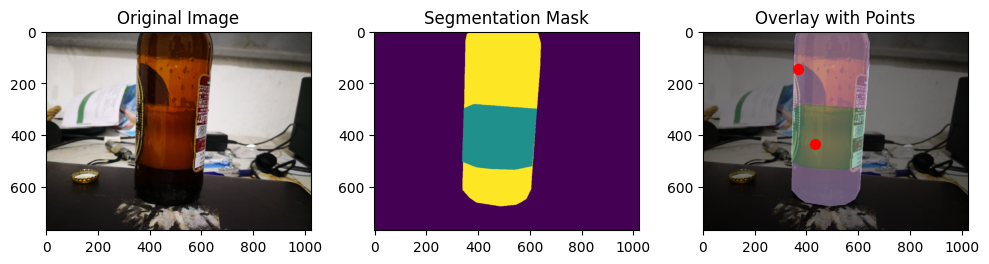

In [7]:
output = dataset[192]
img, mask, points, labels = output["img"], output["mask"], output["points"], output["labels"]

fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Display original image
axes[0].imshow(img)
axes[0].set_title('Original Image')

# Create and display segmentation mask with background
bg_mask = (np.sum(mask, axis=0) == 0).astype(float)
new_mask = np.vstack([bg_mask[np.newaxis, :, :], mask])
axes[1].imshow(new_mask.argmax(0))
axes[1].set_title('Segmentation Mask')

# Create colored overlay with points
colorful = np.zeros_like(img, dtype=float)
for ind in range(mask.shape[0]):
    point = points[ind][0]
    axes[2].scatter(point[0], point[1], c='red', s=50)
    
    binary_mask = mask[ind]
    random_color = np.random.randint(0, 255, size=3)
    colored_mask = binary_mask[:, :, np.newaxis] * random_color
    colorful += colored_mask

final_mask = 0.5 * colorful + 0.5 * img
axes[2].imshow(final_mask.astype(np.uint8))
axes[2].set_title('Overlay with Points')

plt.tight_layout()
plt.show()

In [ ]:
checkpoint = "#Set_This_Path#/sam2_hiera_large.pt"
model_cfg = "configs/sam2/sam2_hiera_l.yaml"
predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))


In [9]:
predictor.model.sam_prompt_encoder.train(True)
predictor.model.sam_mask_decoder.train(True)

MaskDecoder(
  (transformer): TwoWayTransformer(
    (layers): ModuleList(
      (0-1): 2 x TwoWayAttentionBlock(
        (self_attn): Attention(
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (k_proj): Linear(in_features=256, out_features=256, bias=True)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (cross_attn_token_to_image): Attention(
          (q_proj): Linear(in_features=256, out_features=128, bias=True)
          (k_proj): Linear(in_features=256, out_features=128, bias=True)
          (v_proj): Linear(in_features=256, out_features=128, bias=True)
          (out_proj): Linear(in_features=128, out_features=256, bias=True)
        )
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (layers): ModuleList(
    

In [10]:
import torch
scaler = torch.amp.GradScaler(device="cuda")
optimizer = torch.optim.AdamW(predictor.model.parameters(), lr=1e-4, weight_decay=5e-4)

In [11]:
class AverageMeter:
    """
    Computes and stores the average and current value.
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count if self.count > 0 else 0

In [12]:
accumulation_step = 4
import tqdm
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
ScoreLoss = AverageMeter()
CELoss = AverageMeter()
for epoch in range(10):
    with tqdm.tqdm(dataloader, desc=f"Epoch {epoch+1}/10") as pbar:
        for step, output in enumerate(pbar):
            with torch.amp.autocast(device_type="cuda"):
                img, mask_gt, points, labels = output["img"], output["mask"], output["points"], output["labels"]
                img = img.cpu().numpy()
                if len(mask_gt) == 0:
                    continue
                predictor.set_image(img[0])
                mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(
                        points[0], labels[0], None, None, True
                    )
                concat_points = (unnorm_coords, labels)
                sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
                    points=concat_points,
                    boxes=None,
                    masks=mask_input,
                )
                batched_mode = (
                    concat_points is not None and concat_points[0].shape[0] > 1
                )
                high_res_features = [
                    feat_level[-1].unsqueeze(0)
                    for feat_level in predictor._features["high_res_feats"]
                ]
                low_res_masks, iou_predictions, _, _ = predictor.model.sam_mask_decoder(
                    image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
                    image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_embeddings,
                    dense_prompt_embeddings=dense_embeddings,
                    multimask_output=True,
                    repeat_image=batched_mode,
                    high_res_features=high_res_features,
                )
                masks = predictor._transforms.postprocess_masks(
                    low_res_masks, predictor._orig_hw[-1]
                )
                mask_pred = torch.sigmoid(masks[:, 0])
                mask_pred = mask_pred.to("cuda")
                mask_gt = mask_gt[0].to("cuda")
                ce = mask_gt * torch.log(mask_pred+1e-10) + (1-mask_gt) * torch.log(1-mask_pred+1e-10)
                loss_ce = -1*ce.mean()
                CELoss.update(loss_ce.item())
                
                inter = ((mask_pred > 0.5)*mask_gt).sum(1).sum(1)
                union = (mask_pred>0.5).sum(1).sum(1) + mask_gt.sum(1).sum(1) - inter
                iou = inter/union
                score_loss = ((iou - iou_predictions[:, 0])**2).mean()
                ScoreLoss.update(iou.mean().item())
                
                loss = loss_ce+score_loss*0.05
            
                # Backward pass outside autocast
                scaler.scale(loss).backward()
            
                # Update weights every accumulation_step
                if (step + 1) % accumulation_step == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    predictor.model.zero_grad()
            
            pbar.set_postfix({"CE Loss": f'{CELoss.avg:.4f}', "IoU": f'{ScoreLoss.avg:.4f}'})
            
            if step % 100 == 0 and step > 0:
                CELoss.reset()
                ScoreLoss.reset()

Epoch 10/10: 100%|██████████| 1691/1691 [03:10<00:00,  8.89it/s, CE Loss=0.1511, IoU=0.6565]


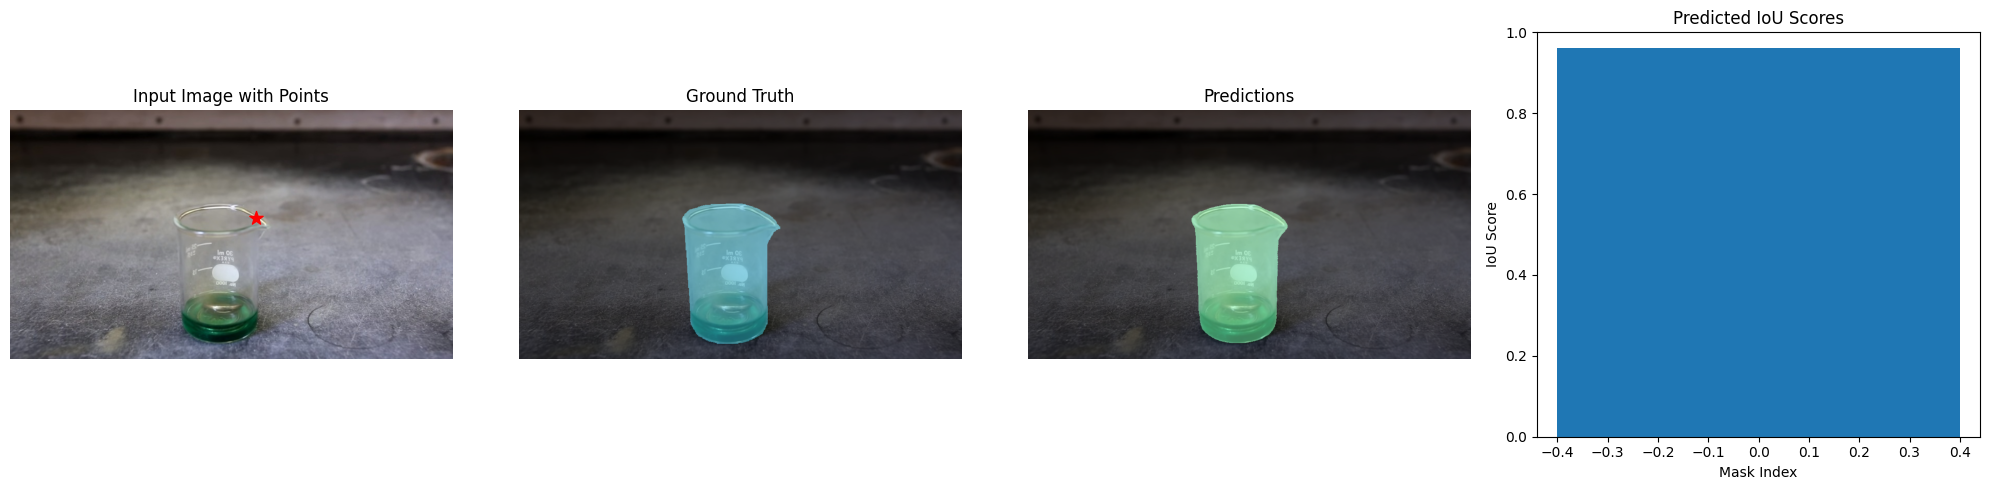

Mean IoU Score: 0.962


In [14]:
# Evaluation with visualization
import matplotlib.pyplot as plt

predictor.model.eval()
test_idx = np.random.randint(len(test_dataset))
output = test_dataset[test_idx]
img, mask_gt, points, labels = output["img"], output["mask"], output["points"], output["labels"]

with torch.no_grad():
    predictor.set_image(img)
    mask_input, unnorm_coords, labels_prep, unnorm_box = predictor._prep_prompts(
        points, labels, None, None, True
    )
    masks, iou_predictions, _ = predictor._predict(
        unnorm_coords,
        labels_prep,
        unnorm_box,
        mask_input,
        True,
        return_logits=False,
    )
    # Move to CPU and convert to numpy
    masks = masks.cpu().numpy()
    iou_predictions = iou_predictions.cpu().numpy()
    # Take the first mask output (best mask) for each object
    masks = masks[:, 0, :, :]  # Shape: (num_objects, H, W)

# Visualize results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original image with points
axes[0].imshow(img)
for point in points:
    axes[0].scatter(point[0][0], point[0][1], c='red', s=100, marker='*')
axes[0].set_title('Input Image with Points')
axes[0].axis('off')

# Ground truth masks
gt_viz = np.zeros_like(img, dtype=float)
for i, mask in enumerate(mask_gt):
    color = np.random.randint(50, 255, size=3)
    gt_viz += mask[:, :, None] * color
axes[1].imshow(img)
axes[1].imshow(gt_viz.astype(np.uint8), alpha=0.5)
axes[1].set_title('Ground Truth')
axes[1].axis('off')

# Predicted masks
pred_viz = np.zeros_like(img, dtype=float)
for i, mask in enumerate(masks):
    color = np.random.randint(50, 255, size=3)
    pred_viz += mask[:, :, None] * color
axes[2].imshow(img)
axes[2].imshow(pred_viz.astype(np.uint8), alpha=0.5)
axes[2].set_title('Predictions')
axes[2].axis('off')

# IoU scores
axes[3].bar(range(len(iou_predictions)), iou_predictions[:, 0])
axes[3].set_xlabel('Mask Index')
axes[3].set_ylabel('IoU Score')
axes[3].set_title('Predicted IoU Scores')
axes[3].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Mean IoU Score: {iou_predictions[:, 0].mean():.3f}")

In [ ]:
# Calculate overall IoU on entire dataset (naive model)
predictor.model.eval()
all_ious = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        output = test_dataset[idx]
        img, mask_gt, points, labels = output["img"], output["mask"], output["points"], output["labels"]
        
        if len(mask_gt) == 0:
            continue
            
        predictor.set_image(img)
        mask_input, unnorm_coords, labels_prep, unnorm_box = predictor._prep_prompts(
            points, labels, None, None, True
        )
        masks, _, _ = predictor._predict(
            unnorm_coords,
            labels_prep,
            unnorm_box,
            mask_input,
            True,
            return_logits=False,
        )
        
        # Get best mask for each object
        mask_pred = masks[:, 0, :, :]  # Shape: (num_objects, H, W)
        mask_pred = (mask_pred > 0.5).cpu().numpy()
        
        # Calculate IoU for each object
        for i in range(len(mask_gt)):
            inter = (mask_pred[i] * mask_gt[i]).sum()
            union = mask_pred[i].sum() + mask_gt[i].sum() - inter
            if union > 0:
                iou = inter / union
                all_ious.append(iou)

overall_iou = np.mean(all_ious)
print(f"Overall IoU on {len(dataset)} images: {overall_iou:.4f}")
print(f"Total masks evaluated: {len(all_ious)}")

Overall IoU on 1691 images: 0.4604
Total masks evaluated: 1032


In [ ]:
# Calculate overall IoU on entire dataset (with finetuning)
predictor.model.eval()
all_ious = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        output = test_dataset[idx]
        img, mask_gt, points, labels = output["img"], output["mask"], output["points"], output["labels"]
        
        if len(mask_gt) == 0:
            continue
            
        predictor.set_image(img)
        mask_input, unnorm_coords, labels_prep, unnorm_box = predictor._prep_prompts(
            points, labels, None, None, True
        )
        masks, _, _ = predictor._predict(
            unnorm_coords,
            labels_prep,
            unnorm_box,
            mask_input,
            True,
            return_logits=False,
        )
        
        # Get best mask for each object
        mask_pred = masks[:, 0, :, :]  # Shape: (num_objects, H, W)
        mask_pred = (mask_pred > 0.5).cpu().numpy()
        
        # Calculate IoU for each object
        for i in range(len(mask_gt)):
            inter = (mask_pred[i] * mask_gt[i]).sum()
            union = mask_pred[i].sum() + mask_gt[i].sum() - inter
            if union > 0:
                iou = inter / union
                all_ious.append(iou)

overall_iou = np.mean(all_ious)
print(f"Overall IoU on {len(dataset)} images: {overall_iou:.4f}")
print(f"Total masks evaluated: {len(all_ious)}")

Overall IoU on 1691 images: 0.5520
Total masks evaluated: 1032
